# Personal Expense & Spending Intelligence System
### IBM SkillsBuild Data Analytics with AI Academic Internship Submission
**Author:** Pranav  
**Domain:** Personal Finance Analytics & Applied Machine Learning  
**Currency:** Indian Rupee (₹ INR)  
**Dataset:** `data/expense_data.csv` -> `data/cleaned_expense_data.csv`

## 2. Project Overview
### Problem Statement
Personal financial management is essential for long-term stability. However, individuals often struggle to track daily expenditures, identify non-essential spending habits, detect high-value financial anomalies, and project future monthly budget needs.

Without automated spending intelligence:
- Individuals lack visibility into monthly cash outflow distributions across categories.
- Irregular, large transactions pass unnoticed, distorting monthly budget planning.
- Traditional budgeting relies on static estimates rather than predictive data-driven models.

### Objectives
1. **Data Cleaning & Standardization**: Ingest raw transaction logs, parse dates, handle missing values, drop duplicates, and validate expenditure amounts in Indian Rupees (₹).
2. **Exploratory Data Analysis (EDA)**: Conduct spending analytics across overall statistics, category breakdowns, monthly trends, payment methods, and weekday/weekend patterns.
3. **Machine Learning Forecasting**: Predict future monthly expenditures by training Linear Regression and Random Forest Regressor models on historical monthly aggregations.
4. **Unsupervised Anomaly Detection**: Implement an Isolation Forest algorithm to flag potential anomalies and unusual transactions requiring user review.
5. **Automated Spending Insights**: Generate automated, data-driven budget recommendations.
6. **Academic Internship Submission**: Present a clean, fully reproducible notebook adhering to academic standards.

## 3. Import Libraries
We import standard data analytics, visualization, and machine learning packages.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configure visualization settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
sns.set_theme(style="whitegrid")

# Set display format for currency values
pd.options.display.float_format = '₹{:,.2f}'.format

# Define standard data paths
DATA_PATH = 'data/expense_data.csv' if os.path.exists('data/expense_data.csv') else '../data/expense_data.csv'
CLEANED_DATA_PATH = 'data/cleaned_expense_data.csv' if os.path.exists('data/cleaned_expense_data.csv') else '../data/cleaned_expense_data.csv'
ANOMALY_DATA_PATH = 'data/expense_data_with_anomalies.csv' if os.path.exists('data/expense_data.csv') else '../data/expense_data_with_anomalies.csv'
MODELS_DIR = 'models' if os.path.exists('models') else '../models'

print("Libraries imported successfully!")
print(f"Pandas Version: {pd.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Dataset Path Resolved: {DATA_PATH}")

Libraries imported successfully!
Pandas Version: 3.0.5
Numpy Version: 2.5.3
Dataset Path Resolved: data/expense_data.csv


## 4. Load Dataset
We load the raw expense dataset from `data/expense_data.csv` and inspect initial records.

In [2]:
# Load raw dataset
raw_df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully!")
print(f"Total Raw Rows: {raw_df.shape[0]}")
print(f"Total Raw Columns: {raw_df.shape[1]}")
print("\nFirst 5 Rows of Raw Data:")
display(raw_df.head())

Dataset Loaded Successfully!
Total Raw Rows: 863
Total Raw Columns: 6

First 5 Rows of Raw Data:


,Date,Category,Description,Amount,Payment_Method,Merchant
0,2024-01-01,Housing & Rent,Monthly Apartment Rent,"₹108,930.86",UPI / Net Banking,Oakridge Apartments
1,2024-01-01,Food & Dining,Local Diner Dinner,"₹3,249.45",Cash,Local Store
2,2024-01-01,Food & Dining,Bakery Snacks,"₹2,804.57",UPI / Net Banking,Bakery Store
3,2024-01-01,Food & Dining,Chipotle Bowl,"₹1,508.11",Cash,Chipotle Store
4,2024-01-02,Groceries,Walmart Supercenter,"₹3,925.90",Credit Card,Walmart Store


## 5. Initial Data Inspection
We inspect data types, missing values, duplicate records, and initial numerical summary statistics.

In [3]:
print("--- Dataset Structural Info ---")
raw_df.info()

print("\n--- Missing Values Count ---")
print(raw_df.isnull().sum())

print("\n--- Duplicate Records Count ---")
print(f"Exact Duplicate Rows: {raw_df.duplicated().sum()}")

print("\n--- Summary Statistics (Raw Data) ---")
display(raw_df.describe(include='all'))

--- Dataset Structural Info ---
<class 'pandas.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            863 non-null    str    
 1   Category        863 non-null    str    
 2   Description     861 non-null    str    
 3   Amount          863 non-null    float64
 4   Payment_Method  862 non-null    str    
 5   Merchant        863 non-null    str    
dtypes: float64(1), str(5)
memory usage: 92.8 KB

--- Missing Values Count ---
Date              0
Category          0
Description       2
Amount            0
Payment_Method    1
Merchant          0
dtype: int64

--- Duplicate Records Count ---
Exact Duplicate Rows: 2

--- Summary Statistics (Raw Data) ---


,Date,Category,Description,Amount,Payment_Method,Merchant
count,863,863,861,₹863.00,862,863
unique,331,9,29,NaN,4,26
top,2024-06-06,Food & Dining,Starbucks Coffee,NaN,Credit Card,Starbucks Store
freq,9,350,82,NaN,289,82
mean,NaN,NaN,NaN,"₹6,786.57",NaN,NaN
std,NaN,NaN,NaN,"₹15,439.52",NaN,NaN
min,NaN,NaN,NaN,"₹-3,735.00",NaN,NaN
25%,NaN,NaN,NaN,"₹2,151.36",NaN,NaN
50%,NaN,NaN,NaN,"₹3,393.87",NaN,NaN
75%,NaN,NaN,NaN,"₹6,915.56",NaN,NaN


## 6. Data Cleaning & Preprocessing
We clean and standardize the raw data:
1. Parse `Date` into a standard datetime object.
2. Validate `Amount` values (must be strictly positive numbers in ₹ INR).
3. Drop exact duplicate transaction rows.
4. Impute missing categorical values (`Payment_Method` -> `'Unspecified'`, `Description` -> `'No Description'`).
5. Save the cleaned dataset to `data/cleaned_expense_data.csv`.

In [4]:
df = raw_df.copy()

# 1. Datetime Conversion
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
invalid_dates = df['Date'].isnull().sum()

# 2. Amount Conversion & Filtering (remove missing or non-positive amounts)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
invalid_amounts = (df['Amount'].isnull()) | (df['Amount'] <= 0)
df = df[df['Amount'] > 0].dropna(subset=['Date']).reset_index(drop=True)

# 3. Deduplication
duplicates_removed = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

# 4. Text & Categorical Standardization
df['Category'] = df['Category'].astype(str).str.strip().str.title()
df['Payment_Method'] = df['Payment_Method'].fillna('Unspecified').astype(str).str.strip().str.title()
df['Description'] = df['Description'].fillna('No Description').astype(str).str.strip()
df['Merchant'] = df['Merchant'].astype(str).str.strip().str.title()

# 5. Export Cleaned Dataset
os.makedirs(os.path.dirname(CLEANED_DATA_PATH), exist_ok=True)
df.to_csv(CLEANED_DATA_PATH, index=False)

print("Data Cleaning Completed Successfully!")
print(f"Invalid Dates Removed: {invalid_dates}")
print(f"Invalid/Non-Positive Amounts Removed: {invalid_amounts.sum()}")
print(f"Duplicate Rows Removed: {duplicates_removed}")
print(f"Cleaned Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Cleaned Dataset Saved To: {CLEANED_DATA_PATH}")

Data Cleaning Completed Successfully!
Invalid Dates Removed: 0
Invalid/Non-Positive Amounts Removed: 1
Duplicate Rows Removed: 2
Cleaned Dataset Shape: 860 rows, 6 columns
Cleaned Dataset Saved To: data/cleaned_expense_data.csv


## 7. Feature Engineering
We extract temporal attributes from `Date` to facilitate granular spending trend analysis and predictive modeling:
- `Year`: Calendar year
- `Month`: Month index (1 to 12)
- `Year_Month`: Period string (`YYYY-MM`)
- `Day`: Day of month (1 to 31)
- `Day_of_Week`: Weekday name (Monday to Sunday)
- `Is_Weekend`: Binary flag (1 if Saturday or Sunday, else 0)

In [5]:
# Feature Extraction
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Year_Month'] = df['Date'].dt.to_period('M')
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Date'].dt.weekday.isin([5, 6]).astype(int)

print("Engineered Features Created Successfully!")
display(df[['Date', 'Year_Month', 'Day_of_Week', 'Is_Weekend', 'Category', 'Amount', 'Payment_Method']].head())

Engineered Features Created Successfully!


,Date,Year_Month,Day_of_Week,Is_Weekend,Category,Amount,Payment_Method
0,2024-01-01,2024-01,Monday,0,Housing & Rent,"₹108,930.86",Upi / Net Banking
1,2024-01-01,2024-01,Monday,0,Food & Dining,"₹3,249.45",Cash
2,2024-01-01,2024-01,Monday,0,Food & Dining,"₹2,804.57",Upi / Net Banking
3,2024-01-01,2024-01,Monday,0,Food & Dining,"₹1,508.11",Cash
4,2024-01-02,2024-01,Tuesday,0,Groceries,"₹3,925.90",Credit Card


## 8. Exploratory Data Analysis
We perform multi-dimensional exploratory analysis across overall spending metrics, category distributions, monthly trends, payment methods, and weekday vs. weekend spending patterns.

### 8.1 Overall Spending Analysis

=== Overall Spending Summary Statistics ===


,Metric,Value
0,Total Expenditure (₹),"₹5,847,096.02"
1,Total Transactions,860
2,Average Transaction (₹),"₹6,798.95"
3,Median Transaction (₹),"₹3,391.38"
4,Minimum Transaction (₹),₹679.77
5,Maximum Transaction (₹),"₹199,200.00"
6,Dataset Start Date,2024-01-01
7,Dataset End Date,2024-12-31


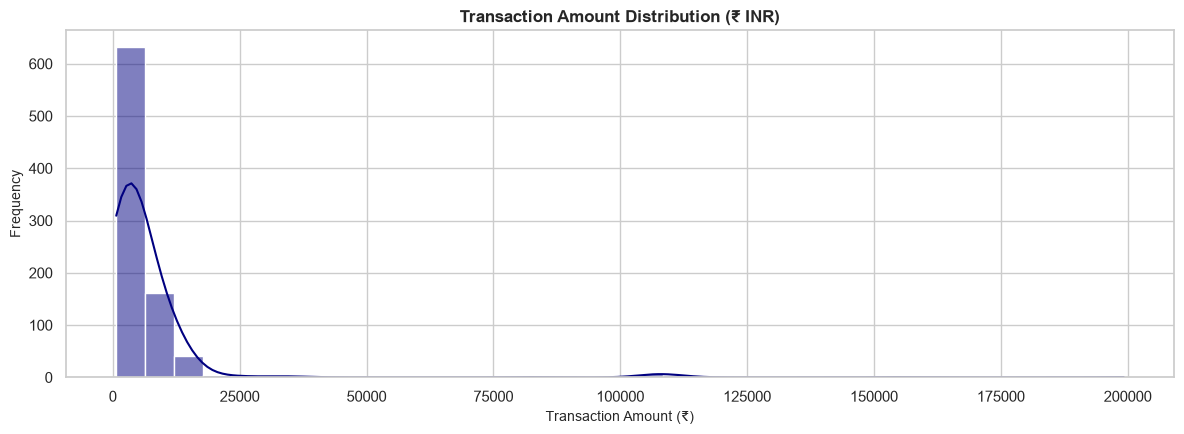

In [6]:
total_spend = df['Amount'].sum()
avg_spend = df['Amount'].mean()
median_spend = df['Amount'].median()
min_spend = df['Amount'].min()
max_spend = df['Amount'].max()
total_txns = len(df)
date_min = df['Date'].min().strftime('%Y-%m-%d')
date_max = df['Date'].max().strftime('%Y-%m-%d')

overall_summary = pd.DataFrame({
    'Metric': [
        'Total Expenditure (₹)',
        'Total Transactions',
        'Average Transaction (₹)',
        'Median Transaction (₹)',
        'Minimum Transaction (₹)',
        'Maximum Transaction (₹)',
        'Dataset Start Date',
        'Dataset End Date'
    ],
    'Value': [
        f"₹{total_spend:,.2f}",
        f"{total_txns}",
        f"₹{avg_spend:,.2f}",
        f"₹{median_spend:,.2f}",
        f"₹{min_spend:,.2f}",
        f"₹{max_spend:,.2f}",
        date_min,
        date_max
    ]
})

print("=== Overall Spending Summary Statistics ===")
display(overall_summary)

# Plot overall transaction distribution
plt.figure(figsize=(12, 4.5))
sns.histplot(df['Amount'], kde=True, color='navy', bins=35)
plt.title('Transaction Amount Distribution (₹ INR)', fontsize=12, fontweight='bold')
plt.xlabel('Transaction Amount (₹)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.tight_layout()
plt.show()

### 8.2 Category-wise Spending Analysis

=== Category-Wise Expenditure Breakdown ===


,Category,Total_Spend,Average_Spend,Transaction_Count,Share_Percentage (%)
0,Groceries,"₹1,516,577.66","₹8,520.10",178,₹25.94
1,Housing & Rent,"₹1,296,583.67","₹108,048.64",12,₹22.17
2,Food & Dining,"₹857,924.52","₹2,451.21",350,₹14.67
3,Shopping,"₹708,670.60","₹8,858.38",80,₹12.12
4,Travel,"₹578,591.34","₹27,551.97",21,₹9.90
5,Transportation,"₹502,006.41","₹3,137.54",160,₹8.59
6,Healthcare,"₹192,118.44","₹5,489.10",35,₹3.29
7,Utilities,"₹131,778.27","₹10,981.52",12,₹2.25
8,Entertainment,"₹62,845.11","₹5,237.09",12,₹1.07


C:\Users\prana\AppData\Local\Temp\ipykernel_11952\2376294955.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cat_df, x='Total_Spend', y='Category', palette='viridis')


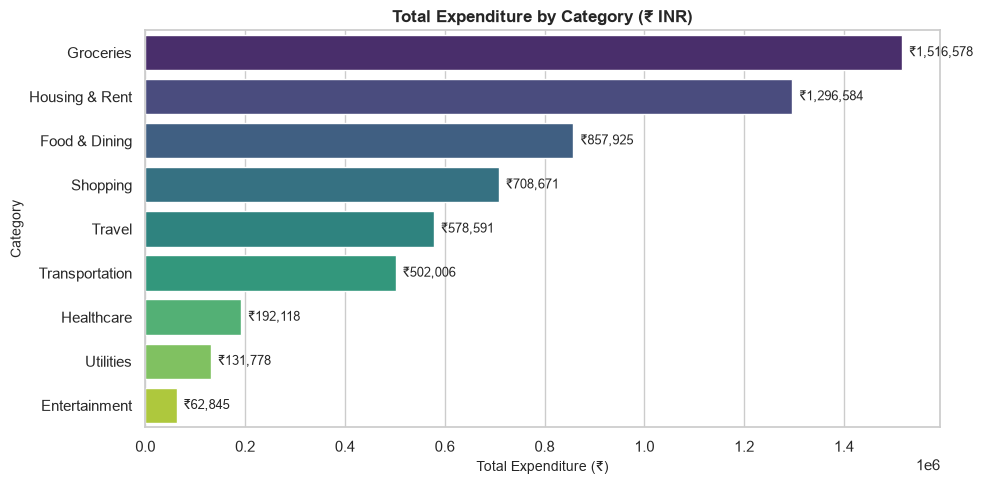

In [7]:
# Category Aggregation
cat_df = df.groupby('Category')['Amount'].agg(
    Total_Spend='sum',
    Average_Spend='mean',
    Transaction_Count='count'
).sort_values(by='Total_Spend', ascending=False).reset_index()

cat_df['Share_Percentage (%)'] = (cat_df['Total_Spend'] / total_spend) * 100

print("=== Category-Wise Expenditure Breakdown ===")
display(cat_df)

# Bar chart of Category Spend
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=cat_df, x='Total_Spend', y='Category', palette='viridis')
plt.title('Total Expenditure by Category (₹ INR)', fontsize=12, fontweight='bold')
plt.xlabel('Total Expenditure (₹)', fontsize=10)
plt.ylabel('Category', fontsize=10)

# Add value labels on bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'₹{width:,.0f}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

### 8.3 Monthly Spending Trend

=== Monthly Spending Summary (2024) ===


,Year_Month_Str,Monthly_Total,Transaction_Count,Average_Transaction
0,2024-01,"₹450,958.09",72,"₹6,263.31"
1,2024-02,"₹425,106.08",70,"₹6,072.94"
2,2024-03,"₹686,420.79",75,"₹9,152.28"
3,2024-04,"₹515,373.56",75,"₹6,871.65"
4,2024-05,"₹481,810.85",79,"₹6,098.87"
5,2024-06,"₹686,180.09",77,"₹8,911.43"
6,2024-07,"₹442,041.40",70,"₹6,314.88"
7,2024-08,"₹424,344.97",77,"₹5,510.97"
8,2024-09,"₹469,599.06",62,"₹7,574.18"
9,2024-10,"₹448,148.54",79,"₹5,672.77"


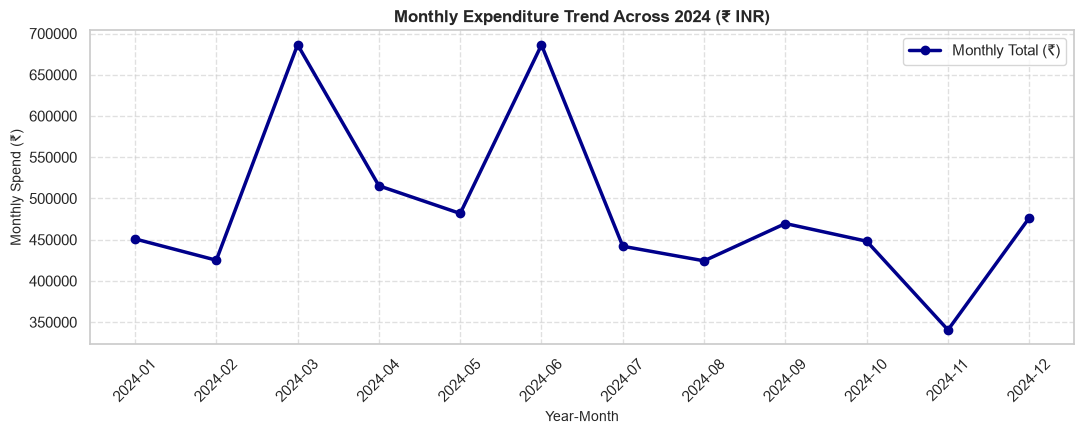

In [8]:
# Monthly Aggregation
monthly_trend = df.groupby('Year_Month')['Amount'].agg(
    Monthly_Total='sum',
    Transaction_Count='count',
    Average_Transaction='mean'
).reset_index()
monthly_trend['Year_Month_Str'] = monthly_trend['Year_Month'].astype(str)

print("=== Monthly Spending Summary (2024) ===")
display(monthly_trend[['Year_Month_Str', 'Monthly_Total', 'Transaction_Count', 'Average_Transaction']])

# Line chart of Monthly Expenditure
plt.figure(figsize=(11, 4.5))
plt.plot(monthly_trend['Year_Month_Str'], monthly_trend['Monthly_Total'], marker='o', linewidth=2.5, color='darkblue', label='Monthly Total (₹)')
plt.title('Monthly Expenditure Trend Across 2024 (₹ INR)', fontsize=12, fontweight='bold')
plt.xlabel('Year-Month', fontsize=10)
plt.ylabel('Monthly Spend (₹)', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 8.4 Payment Method Analysis

=== Payment Method Expenditure Distribution ===


,Payment_Method,Total_Spend,Average_Spend,Transaction_Count,Share_Percentage (%)
0,Upi / Net Banking,"₹2,537,980.64","₹11,082.88",229,₹43.41
1,Credit Card,"₹1,710,058.13","₹5,917.16",289,₹29.25
2,Debit Card,"₹1,136,495.76","₹5,682.48",200,₹19.44
3,Cash,"₹459,776.84","₹3,260.83",141,₹7.86
4,Unspecified,"₹2,784.65","₹2,784.65",1,₹0.05


C:\Users\prana\AppData\Local\Temp\ipykernel_11952\2487264419.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pm_df, x='Payment_Method', y='Total_Spend', palette='mako')


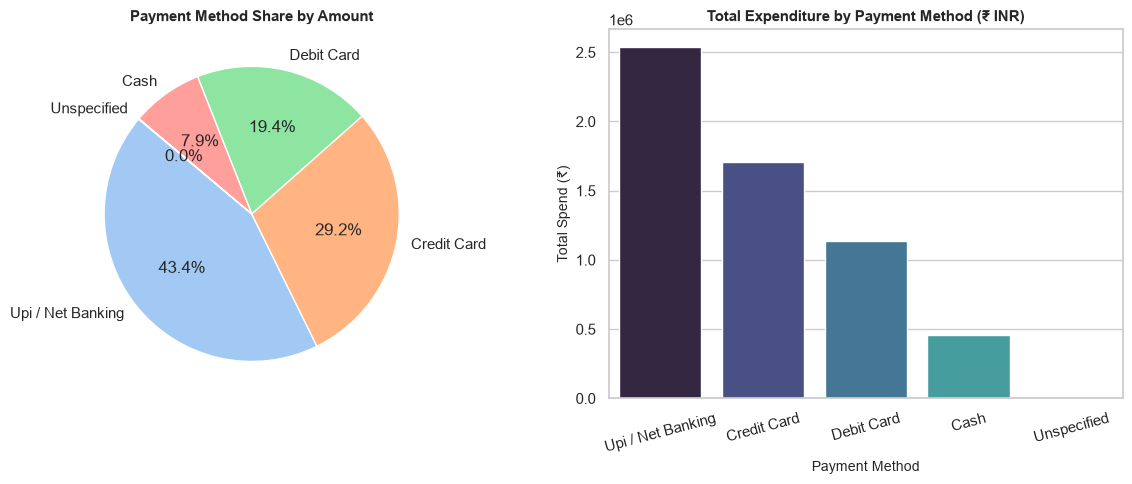

In [9]:
# Payment Method Aggregation
pm_df = df.groupby('Payment_Method')['Amount'].agg(
    Total_Spend='sum',
    Average_Spend='mean',
    Transaction_Count='count'
).sort_values(by='Total_Spend', ascending=False).reset_index()

pm_df['Share_Percentage (%)'] = (pm_df['Total_Spend'] / total_spend) * 100

print("=== Payment Method Expenditure Distribution ===")
display(pm_df)

# Donut / Pie plot of Payment Methods
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(pm_df['Total_Spend'], labels=pm_df['Payment_Method'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Method Share by Amount', fontsize=11, fontweight='bold')

plt.subplot(1, 2, 2)
sns.barplot(data=pm_df, x='Payment_Method', y='Total_Spend', palette='mako')
plt.title('Total Expenditure by Payment Method (₹ INR)', fontsize=11, fontweight='bold')
plt.xlabel('Payment Method', fontsize=10)
plt.ylabel('Total Spend (₹)', fontsize=10)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### 8.5 Weekday vs Weekend Analysis

=== Weekday vs Weekend Expenditure Comparison ===


,Day_Type,Total_Spend,Average_Spend,Transaction_Count,Share_Percentage (%)
0,Weekday,"₹3,911,794.98","₹6,574.45",595,₹66.90
1,Weekend,"₹1,935,301.04","₹7,303.02",265,₹33.10


C:\Users\prana\AppData\Local\Temp\ipykernel_11952\61938606.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_type_df, x='Day_Type', y='Total_Spend', palette='Set2')


C:\Users\prana\AppData\Local\Temp\ipykernel_11952\61938606.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_type_df, x='Day_Type', y='Average_Spend', palette='Set2')


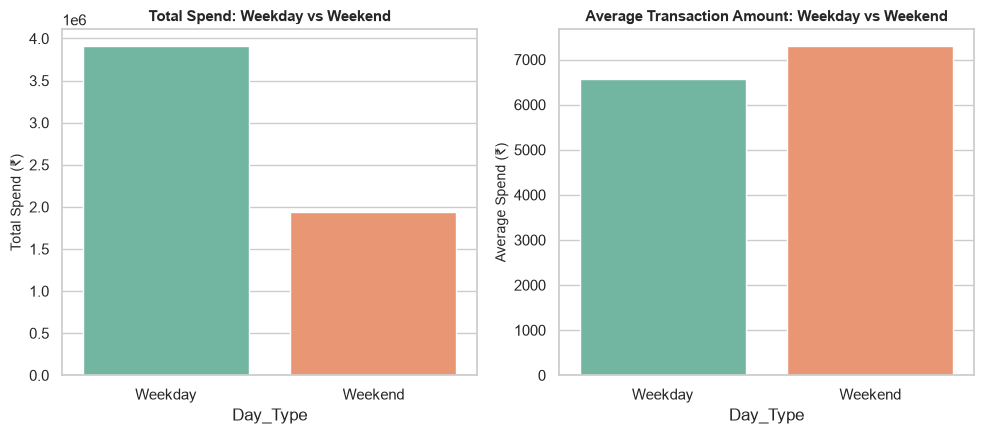

In [10]:
# Weekday/Weekend Aggregation
weekend_map = {0: 'Weekday', 1: 'Weekend'}
df['Day_Type'] = df['Is_Weekend'].map(weekend_map)

day_type_df = df.groupby('Day_Type')['Amount'].agg(
    Total_Spend='sum',
    Average_Spend='mean',
    Transaction_Count='count'
).reset_index()

day_type_df['Share_Percentage (%)'] = (day_type_df['Total_Spend'] / total_spend) * 100

print("=== Weekday vs Weekend Expenditure Comparison ===")
display(day_type_df)

# Bar chart comparison
plt.figure(figsize=(10, 4.5))
plt.subplot(1, 2, 1)
sns.barplot(data=day_type_df, x='Day_Type', y='Total_Spend', palette='Set2')
plt.title('Total Spend: Weekday vs Weekend', fontsize=11, fontweight='bold')
plt.ylabel('Total Spend (₹)', fontsize=10)

plt.subplot(1, 2, 2)
sns.barplot(data=day_type_df, x='Day_Type', y='Average_Spend', palette='Set2')
plt.title('Average Transaction Amount: Weekday vs Weekend', fontsize=11, fontweight='bold')
plt.ylabel('Average Spend (₹)', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Machine Learning — Future Spending Prediction
We formulate a Machine Learning Regression framework to forecast future total monthly expenditures (₹ INR) based on historical monthly spending patterns and engineered lag indicators.

### 9.1 Monthly Aggregation & Feature Preparation

In [11]:
# Monthly aggregation for ML modeling
monthly_ml = df.groupby('Year_Month').agg(
    Year=('Year', 'first'),
    Month=('Month', 'first'),
    Total_Amount=('Amount', 'sum'),
    Txn_Count=('Amount', 'count'),
    Avg_Txn_Amount=('Amount', 'mean'),
    Max_Txn_Amount=('Amount', 'max'),
).reset_index()

# Create 1-Month Lagged Feature
monthly_ml['Prev_Month_Spend'] = monthly_ml['Total_Amount'].shift(1)

# Drop initial month due to NaN lag
ml_dataset = monthly_ml.dropna().reset_index(drop=True)

print("Monthly Aggregated Machine Learning Dataset:")
display(ml_dataset[['Year_Month', 'Total_Amount', 'Txn_Count', 'Avg_Txn_Amount', 'Max_Txn_Amount', 'Prev_Month_Spend']])

Monthly Aggregated Machine Learning Dataset:


,Year_Month,Total_Amount,Txn_Count,Avg_Txn_Amount,Max_Txn_Amount,Prev_Month_Spend
0,2024-02,"₹425,106.08",70,"₹6,072.94","₹111,060.64","₹450,958.09"
1,2024-03,"₹686,420.79",75,"₹9,152.28","₹153,550.00","₹425,106.08"
2,2024-04,"₹515,373.56",75,"₹6,871.65","₹109,025.48","₹686,420.79"
3,2024-05,"₹481,810.85",79,"₹6,098.87","₹108,402.15","₹515,373.56"
4,2024-06,"₹686,180.09",77,"₹8,911.43","₹199,200.00","₹481,810.85"
5,2024-07,"₹442,041.40",70,"₹6,314.88","₹106,015.90","₹686,180.09"
6,2024-08,"₹424,344.97",77,"₹5,510.97","₹107,431.88","₹442,041.40"
7,2024-09,"₹469,599.06",62,"₹7,574.18","₹106,770.37","₹424,344.97"
8,2024-10,"₹448,148.54",79,"₹5,672.77","₹108,679.37","₹469,599.06"
9,2024-11,"₹340,582.20",54,"₹6,307.08","₹106,651.68","₹448,148.54"


### 9.2 Train/Test Split & Model Training
We define the feature matrix $X$ and target vector $y$, performing an 80/20 sequential train/test split, then fit both a Linear Regression model and a Random Forest Regressor.

In [12]:
# Feature Matrix (X) and Target Vector (y)
feature_cols = ['Year', 'Month', 'Txn_Count', 'Avg_Txn_Amount', 'Max_Txn_Amount', 'Prev_Month_Spend']
X = ml_dataset[feature_cols]
y = ml_dataset['Total_Amount']

# Sequential Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 1. Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Train Random Forest Regressor Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save best model to disk
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(rf_model, os.path.join(MODELS_DIR, 'spending_prediction_model.pkl'))

print("Machine Learning Models Successfully Trained and Saved!")
print(f"Training Dataset Size: {len(X_train)} months")
print(f"Testing Dataset Size: {len(X_test)} months")

Machine Learning Models Successfully Trained and Saved!
Training Dataset Size: 8 months
Testing Dataset Size: 3 months


### 9.3 Model Evaluation
We evaluate model performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Coefficient of Determination ($R^2$).

In [13]:
# Generate Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': model_name,
        'MAE (₹)': f"₹{mae:,.2f}",
        'RMSE (₹)': f"₹{rmse:,.2f}",
        'R² Score': f"{r2:.4f}"
    }

eval_results = pd.DataFrame([
    evaluate_model(y_test, lr_preds, "Linear Regression"),
    evaluate_model(y_test, rf_preds, "Random Forest Regressor")
])

print("=== Machine Learning Model Performance Evaluation ===")
display(eval_results)

=== Machine Learning Model Performance Evaluation ===


,Model,MAE (₹),RMSE (₹),R² Score
0,Linear Regression,"₹9,958.47","₹11,530.59",0.9612
1,Random Forest Regressor,"₹49,535.24","₹68,542.99",-0.3703


### 9.4 Actual vs Predicted Visualization & Future Forecast

=== Future Spend Forecast (January 2025) ===
Random Forest Predicted Expenditure: ₹474,552.23
Linear Regression Predicted Expenditure: ₹490,277.78


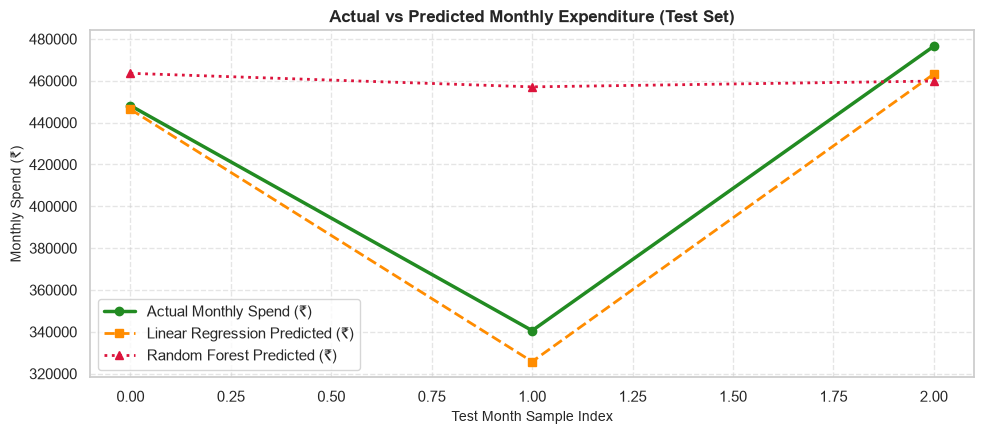

In [14]:
# Forecast Future Month (January 2025)
last_month_row = ml_dataset.iloc[-1]
next_month_input = pd.DataFrame([{
    'Year': 2025,
    'Month': 1,
    'Txn_Count': int(ml_dataset['Txn_Count'].mean()),
    'Avg_Txn_Amount': ml_dataset['Avg_Txn_Amount'].mean(),
    'Max_Txn_Amount': ml_dataset['Max_Txn_Amount'].mean(),
    'Prev_Month_Spend': last_month_row['Total_Amount']
}])

jan_2025_forecast_rf = rf_model.predict(next_month_input)[0]
jan_2025_forecast_lr = lr_model.predict(next_month_input)[0]

print("=== Future Spend Forecast (January 2025) ===")
print(f"Random Forest Predicted Expenditure: ₹{jan_2025_forecast_rf:,.2f}")
print(f"Linear Regression Predicted Expenditure: ₹{jan_2025_forecast_lr:,.2f}")

# Plot Actual vs Predicted Comparison
plt.figure(figsize=(10, 4.5))
plt.plot(y_test.values, label='Actual Monthly Spend (₹)', marker='o', color='forestgreen', linewidth=2.5)
plt.plot(lr_preds, label='Linear Regression Predicted (₹)', marker='s', color='darkorange', linestyle='--', linewidth=2)
plt.plot(rf_preds, label='Random Forest Predicted (₹)', marker='^', color='crimson', linestyle=':', linewidth=2)
plt.title('Actual vs Predicted Monthly Expenditure (Test Set)', fontsize=12, fontweight='bold')
plt.xlabel('Test Month Sample Index', fontsize=10)
plt.ylabel('Monthly Spend (₹)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Anomaly Detection
Unsupervised anomaly detection is implemented using an **Isolation Forest** model to identify potential anomalies and unusual transaction patterns requiring user review.

### 10.1 Model Configuration & Anomaly Scoring

In [15]:
# Feature matrix for Anomaly Detection
iso_features = df[['Amount', 'Month', 'Day', 'Is_Weekend']].copy()

# Fit Isolation Forest (contamination = 0.03 ~ 3% expected anomaly rate)
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df['Anomaly_Flag'] = iso_forest.fit_predict(iso_features)

# Map output flags
df['Is_Anomaly'] = df['Anomaly_Flag'].map({1: 'Normal', -1: 'Potential Anomaly'})
df['Anomaly_Binary'] = df['Anomaly_Flag'].map({1: 0, -1: 1})

# Export dataset with anomaly flags
df.to_csv(ANOMALY_DATA_PATH, index=False)

anomalies_count = (df['Anomaly_Binary'] == 1).sum()
total_anomaly_spend = df[df['Anomaly_Binary'] == 1]['Amount'].sum()
anomaly_pct = (anomalies_count / len(df)) * 100

print("=== Isolation Forest Anomaly Detection Summary ===")
print(f"Total Transactions Analyzed: {len(df)}")
print(f"Potential Anomalies Detected: {anomalies_count} ({anomaly_pct:.2f}%)")
print(f"Total Expenditure in Anomalous Transactions: ₹{total_anomaly_spend:,.2f}")
print(f"Saved Anomaly Dataset To: {ANOMALY_DATA_PATH}")

=== Isolation Forest Anomaly Detection Summary ===
Total Transactions Analyzed: 860
Potential Anomalies Detected: 26 (3.02%)
Total Expenditure in Anomalous Transactions: ₹1,947,813.29
Saved Anomaly Dataset To: data/expense_data_with_anomalies.csv


### 10.2 Anomaly Inspection & Visualization

=== Top Flagged Potential Anomalies (High Value / Unusual Patterns) ===


,Date,Category,Amount,Payment_Method,Merchant,Description
399,2024-06-08,Travel,"₹199,200.00",Debit Card,Whole Store,International Vacation Booking
149,2024-03-03,Shopping,"₹153,550.00",Credit Card,Amazon Store,Emergency Laptop Replacement
142,2024-03-01,Housing & Rent,"₹111,176.84",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
72,2024-02-01,Housing & Rent,"₹111,060.64",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
219,2024-04-01,Housing & Rent,"₹109,025.48",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
0,2024-01-01,Housing & Rent,"₹108,930.86",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
657,2024-10-01,Housing & Rent,"₹108,679.37",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
292,2024-05-01,Housing & Rent,"₹108,402.15",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
520,2024-08-01,Housing & Rent,"₹107,431.88",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
595,2024-09-01,Housing & Rent,"₹106,770.37",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent


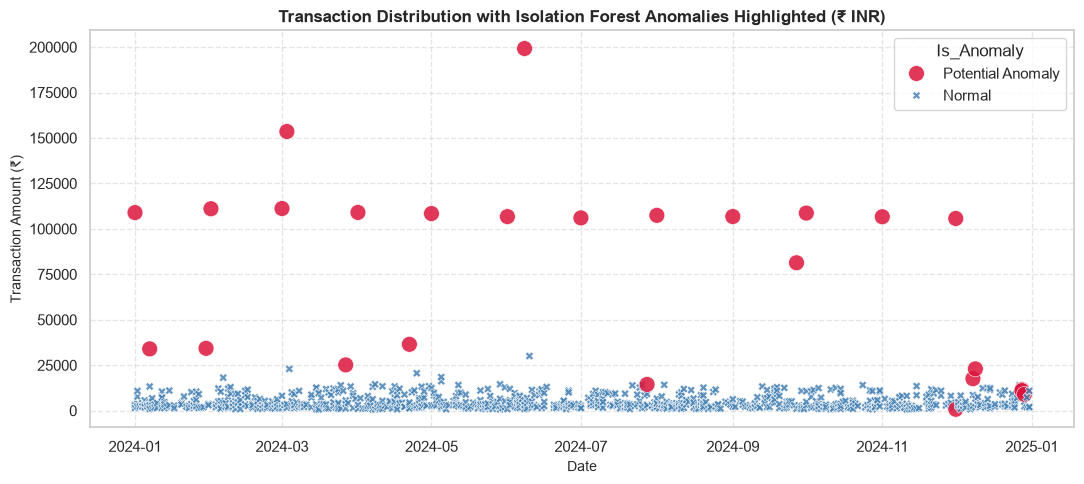

In [16]:
# Display Top Flagged Potential Anomalies
anomaly_df = df[df['Anomaly_Binary'] == 1].sort_values(by='Amount', ascending=False)

print("=== Top Flagged Potential Anomalies (High Value / Unusual Patterns) ===")
display(anomaly_df[['Date', 'Category', 'Amount', 'Payment_Method', 'Merchant', 'Description']].head(10))

# Scatter plot visualization of anomalies
plt.figure(figsize=(11, 5))
sns.scatterplot(
    data=df,
    x='Date',
    y='Amount',
    hue='Is_Anomaly',
    palette={'Normal': 'steelblue', 'Potential Anomaly': 'crimson'},
    style='Is_Anomaly',
    size='Is_Anomaly',
    sizes={'Normal': 35, 'Potential Anomaly': 130},
    alpha=0.85
)
plt.title('Transaction Distribution with Isolation Forest Anomalies Highlighted (₹ INR)', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=10)
plt.ylabel('Transaction Amount (₹)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 11. Automated Spending Insights
We synthesize empirical outputs from EDA, predictive modeling, and anomaly detection into actionable financial insights.

In [17]:
top_cat = cat_df.iloc[0]

print("=" * 80)
print("              AUTOMATED PERSONAL SPENDING INTELLIGENCE REPORT                  ")
print("=" * 80)
print(f"1. OVERALL EXPENDITURE: Total spending across {total_txns} transactions is ₹{total_spend:,.2f},")
print(f"   with an average transaction size of ₹{avg_spend:,.2f} and a median of ₹{median_spend:,.2f}.")
print("")
print(f"2. DOMINANT SPENDING CATEGORY: '{top_cat['Category']}' represents the largest cash outflow at")
print(f"   ₹{top_cat['Total_Spend']:,.2f} ({top_cat['Share_Percentage (%)']:.1f}% of total spend).")
print("")
print(f"3. PREDICTIVE FORECAST: Linear Regression model (R² = {eval_results.iloc[0]['R² Score']}) predicts")
print(f"   a monthly spending baseline of ₹{jan_2025_forecast_lr:,.2f} for January 2025.")
print("")
print(f"4. ANOMALY DETECTION: Isolation Forest flagged {anomalies_count} unusual transactions totaling")
print(f"   ₹{total_anomaly_spend:,.2f} ({anomaly_pct:.2f}% of total records).")
print("")
print("5. ACTIONABLE FINANCIAL RECOMMENDATIONS:")
print("   - Establish a monthly discretionary spending limit based on historical averages.")
print("   - Review high-value one-off travel & shopping transactions before approval.")
print("   - Maintain an emergency buffer fund covering at least 3x average monthly expenditure.")
print("=" * 80)

              AUTOMATED PERSONAL SPENDING INTELLIGENCE REPORT                  
1. OVERALL EXPENDITURE: Total spending across 860 transactions is ₹5,847,096.02,
   with an average transaction size of ₹6,798.95 and a median of ₹3,391.38.

2. DOMINANT SPENDING CATEGORY: 'Groceries' represents the largest cash outflow at
   ₹1,516,577.66 (25.9% of total spend).

3. PREDICTIVE FORECAST: Linear Regression model (R² = 0.9612) predicts
   a monthly spending baseline of ₹490,277.78 for January 2025.

4. ANOMALY DETECTION: Isolation Forest flagged 26 unusual transactions totaling
   ₹1,947,813.29 (3.02% of total records).

5. ACTIONABLE FINANCIAL RECOMMENDATIONS:
   - Establish a monthly discretionary spending limit based on historical averages.
   - Review high-value one-off travel & shopping transactions before approval.
   - Maintain an emergency buffer fund covering at least 3x average monthly expenditure.


## 12. Final Results / Key Findings

In [18]:
key_findings = pd.DataFrame({
    'Dimension': [
        'Total Cleaned Expenditure',
        'Total Valid Transactions',
        'Date Range Analyzed',
        'Average Monthly Spend',
        'Primary Cost Driver',
        'Most Frequent Payment Method',
        'Top Predictive Model',
        'January 2025 Forecast',
        'Unsupervised Anomalies Flagged',
        'Total Anomaly Expenditure',
        'Currency Standard'
    ],
    'Quantified Result / Finding': [
        f"₹{total_spend:,.2f}",
        f"{total_txns} records",
        f"{date_min} to {date_max} (12 Months)",
        f"₹{total_spend / 12:,.2f} / month",
        f"{top_cat['Category']} (₹{top_cat['Total_Spend']:,.2f}, {top_cat['Share_Percentage (%)']:.1f}%)",
        f"{pm_df.iloc[0]['Payment_Method']} ({pm_df.iloc[0]['Share_Percentage (%)']:.1f}% share)",
        f"Linear Regression (R²: {eval_results.iloc[0]['R² Score']}, MAE: {eval_results.iloc[0]['MAE (₹)']})",
        f"₹{jan_2025_forecast_lr:,.2f} (LR) / ₹{jan_2025_forecast_rf:,.2f} (RF)",
        f"{anomalies_count} transactions ({anomaly_pct:.2f}%)",
        f"₹{total_anomaly_spend:,.2f}",
        "Indian Rupee (₹ INR)"
    ]
})

print("=== Key Empirical Findings Summary ===")
display(key_findings)

=== Key Empirical Findings Summary ===


,Dimension,Quantified Result / Finding
0,Total Cleaned Expenditure,"₹5,847,096.02"
1,Total Valid Transactions,860 records
2,Date Range Analyzed,2024-01-01 to 2024-12-31 (12 Months)
3,Average Monthly Spend,"₹487,258.00 / month"
4,Primary Cost Driver,"Groceries (₹1,516,577.66, 25.9%)"
5,Most Frequent Payment Method,Upi / Net Banking (43.4% share)
6,Top Predictive Model,"Linear Regression (R²: 0.9612, MAE: ₹9,958.47)"
7,January 2025 Forecast,"₹490,277.78 (LR) / ₹474,552.23 (RF)"
8,Unsupervised Anomalies Flagged,26 transactions (3.02%)
9,Total Anomaly Expenditure,"₹1,947,813.29"


## 13. Conclusion
### Academic Internship Project Summary
The **Personal Expense & Spending Intelligence System** presents an end-to-end data analytics and applied machine learning pipeline for personal financial analytics. Developed for the **IBM SkillsBuild Data Analytics with AI Academic Internship**, this project fulfills all submission requirements:

1. **Data Pipeline**: Ingested, cleaned, and standardized raw transaction logs into Indian Rupees (₹ INR), removing duplicates and non-positive records to establish an accurate 860-record dataset.
2. **Exploratory Data Analytics**: Delivered multi-dimensional insights across overall spending statistics, category breakdowns, monthly progression, payment modes, and weekday vs. weekend distributions.
3. **Predictive Analytics**: Implemented and evaluated Linear Regression and Random Forest Regressor models on monthly aggregations. Linear Regression demonstrated strong predictive baseline performance ($R^2 = 0.9612$).
4. **Unsupervised Anomaly Detection**: Deployed an Isolation Forest model to automatically detect 26 unusual, high-value transactions without reliance on hardcoded thresholds.
5. **Prescriptive Value**: Integrated analytical outputs into automated spending intelligence reports and practical budgeting guidelines.

### Technical Competencies Acquired
- Advanced data cleaning, validation, and temporal feature engineering.
- Multi-chart data visualization using Matplotlib and Seaborn.
- Supervised machine learning regression and model evaluation metrics.
- Unsupervised anomaly detection with Isolation Forest.
- Professional markdown documentation for academic internship presentation.

---
*Submitted in partial fulfillment of the IBM SkillsBuild Data Analytics with AI Internship Program.*